In [1]:
import numpy as np
import galois

In [2]:
from numpy.random import normal
from scipy.stats import norm
import matplotlib.pyplot as plt

def random_probability_vector(n) -> np.ndarray:
    random_vector = np.abs(normal(size=(2**n,)))
    return random_vector / np.sum(random_vector)

def discretized_normal_probability(interval: tuple[float, float], num_bins: int) -> np.ndarray:

    min_val, max_val = interval
    bins = np.linspace(min_val, max_val, num_bins + 1)
    probabilities = []
    
    for i in range(num_bins):
        prob = norm.cdf(bins[i+1]) - norm.cdf(bins[i])
        probabilities.append(prob)
        
    probability_vector = np.array(probabilities)
    probability_vector /= np.sum(probability_vector) #normalize
    return probability_vector


def plot_distributions(distributions: np.ndarray, title: str):
    if type(distributions) is not list:
        distributions = [distributions]
    for distribution in distributions:
        plt.bar(range(len(distribution)), distribution, alpha=0.5)
    plt.title(title)
    plt.xlabel('Index')
    plt.ylabel('Probability')
    plt.show()

def uniform_like(p):
    return np.ones_like(p) / p.size

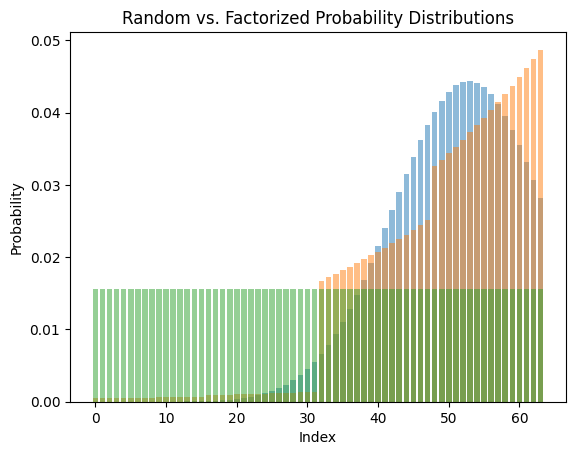

In [3]:
from qfso.models.statevector import factorized

n=6
#p = random_probability_vector(n)
p = discretized_normal_probability((-5, 1), 2**n,)
q = factorized.match_first_order(p)
u = uniform_like(p)
plot_distributions([p,q,u], "Random vs. Factorized Probability Distributions")

In [37]:
from scipy.linalg import hadamard
from qfso.distributions.transform.wh.utils import get_wh_coefficients_in_range

def hamming_weight(k:int):
    return k.bit_count()

def sorted_mmd_contributions(distribution, sigma, hw_min, hw_max):

    n = int(np.log2(distribution.size))
    p = 0.5*(1-np.exp(-1/(2*sigma)))
    weight = lambda hw: (p**hw)*((1-p)**(n-hw))

    fourier_coeffs = get_wh_coefficients_in_range(distribution, n, hw_min, hw_max)
    mmd_contributions =  [(k,weight(k)*(c**2), c) for k,c in fourier_coeffs.items()]
    return list(sorted(mmd_contributions, key=lambda item: item[1], reverse=True))

In [39]:
sigma = 0.01*n
contributions = sorted_mmd_contributions(p, sigma=sigma, hw_min=1, hw_max=3)
for k, c, _ in contributions:
    print(f"{k}\t({k:06b}) -> {c}")

32	(100000) -> 0.013787144216464122
16	(010000) -> 0.0015909143920807877
48	(110000) -> 0.0010909808002733921
56	(111000) -> 0.000731138634780577
24	(011000) -> 0.0004963105502306587
8	(001000) -> 0.00017714989951594373
52	(110100) -> 0.0001653669022859078
20	(010100) -> 0.0001031427872338157
40	(101000) -> 6.61282548151077e-05
4	(000100) -> 4.537996512476634e-05
50	(110010) -> 4.049051660373024e-05
28	(011100) -> 2.8987920611673268e-05
18	(010010) -> 2.4738922076871216e-05
44	(101100) -> 2.3852892210325133e-05
36	(100100) -> 1.449991258594398e-05
2	(000010) -> 1.1363859447984793e-05
49	(110001) -> 1.0074186021099707e-05
12	(001100) -> 8.311058813406059e-06
26	(011010) -> 6.6798941759555895e-06
17	(010001) -> 6.1239471377002025e-06
42	(101010) -> 5.915827812408717e-06
34	(100010) -> 3.480339128063286e-06
1	(000001) -> 2.8424424304172625e-06
10	(001010) -> 2.000663417054129e-06
25	(011001) -> 1.6382132029342954e-06
41	(101001) -> 1.4762768052003015e-06
38	(100110) -> 1.4298838098825657e

In [42]:
def int_to_bin(i:int, n:int):
    string_array = bin(i)[2:].zfill(n)
    return [int(bit) for bit in string_array]

def biggest_independent_set(contributions, n):
    
    Z2 = galois.GF2

    independent_set = [int_to_bin(contributions[0][0], n)]
    fourier_set = [contributions[0][2]]
    for k, _, c in contributions[1:]:
        candidate = int_to_bin(k, n)
        generartors = Z2(independent_set + [candidate])
        if np.linalg.matrix_rank(generartors) == len(independent_set)+1:
            independent_set.append(candidate)
            fourier_set.append(c)
        if len(independent_set) >= n:
            break
        
    return Z2(independent_set), fourier_set


In [44]:
bis = biggest_independent_set(contributions, n)

In [87]:
def match_biggest(bis):

    n = len(bis[1])
    marginals = [[0.5*(1+fc), 0.5*(1-fc)] for fc in bis[1]]
    before_inverse = {}
    for i in range(2**n):
        bits = int_to_bin(i, n)
        before_inverse[i] = np.prod([m[0] if bits[j]==0 else m[1] for j, m in enumerate(marginals)])
    
    mat = np.linalg.inv(bis[0])
    Z2 = galois.GF2
    
    p = np.zeros(2**n)
    for i in range(2**n):
        
        bits = int_to_bin(i, n)
        new_bits = mat@Z2(bits)
        new_i = np.packbits(np.array(new_bits), bitorder="little")[0]
        p[new_i] = before_inverse[i]
        print(bits, new_bits, new_i, new_bits[0])
    
    return p

In [88]:
u_b = match_biggest(bis)

[0, 0, 0, 0, 0, 0] [0 0 0 0 0 0] 0 0
[0, 0, 0, 0, 0, 1] [0 0 0 0 0 1] 32 0
[0, 0, 0, 0, 1, 0] [0 0 0 0 1 0] 16 0
[0, 0, 0, 0, 1, 1] [0 0 0 0 1 1] 48 0
[0, 0, 0, 1, 0, 0] [0 0 0 1 0 0] 8 0
[0, 0, 0, 1, 0, 1] [0 0 0 1 0 1] 40 0
[0, 0, 0, 1, 1, 0] [0 0 0 1 1 0] 24 0
[0, 0, 0, 1, 1, 1] [0 0 0 1 1 1] 56 0
[0, 0, 1, 0, 0, 0] [0 0 1 0 0 0] 4 0
[0, 0, 1, 0, 0, 1] [0 0 1 0 0 1] 36 0
[0, 0, 1, 0, 1, 0] [0 0 1 0 1 0] 20 0
[0, 0, 1, 0, 1, 1] [0 0 1 0 1 1] 52 0
[0, 0, 1, 1, 0, 0] [0 0 1 1 0 0] 12 0
[0, 0, 1, 1, 0, 1] [0 0 1 1 0 1] 44 0
[0, 0, 1, 1, 1, 0] [0 0 1 1 1 0] 28 0
[0, 0, 1, 1, 1, 1] [0 0 1 1 1 1] 60 0
[0, 1, 0, 0, 0, 0] [0 1 1 1 1 1] 62 0
[0, 1, 0, 0, 0, 1] [0 1 1 1 1 0] 30 0
[0, 1, 0, 0, 1, 0] [0 1 1 1 0 1] 46 0
[0, 1, 0, 0, 1, 1] [0 1 1 1 0 0] 14 0
[0, 1, 0, 1, 0, 0] [0 1 1 0 1 1] 54 0
[0, 1, 0, 1, 0, 1] [0 1 1 0 1 0] 22 0
[0, 1, 0, 1, 1, 0] [0 1 1 0 0 1] 38 0
[0, 1, 0, 1, 1, 1] [0 1 1 0 0 0] 6 0
[0, 1, 1, 0, 0, 0] [0 1 0 1 1 1] 58 0
[0, 1, 1, 0, 0, 1] [0 1 0 1 1 0] 26 0
[0, 1, 1, 0, 1, 

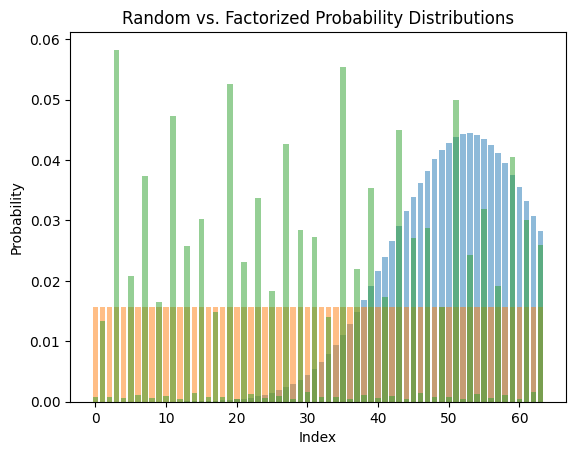

In [89]:
plot_distributions([p,u,u_b], "Random vs. Factorized Probability Distributions")